In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import sys
sys.path.append('/content/drive/MyDrive/DPAS/HW3')

In [3]:
from step1_deidentification import (
    load_images,
    pixelize,
    gaussian_blur,
    compute_metrics,
    plot_pixelization_results,
    plot_blur_results,
    plot_metrics_summary,
    save_processed_dataset,
)

In [4]:
from step2_attack import (
    run_attack,
    plot_attack_results,
    print_results_table,
    plot_loss_curves,
)

In [5]:
from step3_defense import (
    save_dp_dataset,
    run_dp_attack,
    plot_dp_metrics,
    plot_dp_visual_comparison,
    plot_dp_attack_results,
    print_dp_results_table,
)

# Step 1

In [6]:
# Download & load dataset
images, labels = load_images()

Loading Olivetti (AT&T) face dataset...
downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data
Loaded 400 images — 40 subjects x 10 images, size 64x64


In [7]:
# Visualize pixelization
plot_pixelization_results(images, block_sizes=[4, 8, 16])


Saved visualization to step1_pixelization.png


In [8]:
# Visualize Gaussian blur
plot_blur_results(images, kernel_sizes=[15, 45, 99])

Saved: step1_gaussian_blur.png


In [9]:
# Metrics summary charts
plot_metrics_summary(images, block_sizes=[2, 4, 8, 16], kernel_sizes=[15, 45, 99])


Saved: step1_metrics.png


In [10]:
# Save processed dataset for Step 2
save_processed_dataset(images, labels, out_dir='/content/drive/MyDrive/HW3/DPAS/processed_faces')



Processed dataset saved to '/content/drive/MyDrive/HW3/DPAS/processed_faces/' (400 images × 7 versions)
This folder will be used as input for Step 2 (CNN Attack).


# Step 2

In [11]:
# Run attack on all faces
results = run_attack(
    processed_dir='/content/drive/MyDrive/HW3/DPAS/processed_faces',
    num_epochs=50,
    batch_size=32,
)

Using device: cuda

── Training on: original ──────────────────────
  Epoch [10/50] Loss: 0.7454
  Epoch [20/50] Loss: 0.2324
  Epoch [30/50] Loss: 0.1926
  Epoch [40/50] Loss: 0.1413
  Epoch [50/50] Loss: 0.1439
  -> Top-1: 96.25%  |  Top-5: 100.00%

── Training on: pix_b4 ──────────────────────
  Epoch [10/50] Loss: 0.7411
  Epoch [20/50] Loss: 0.2930
  Epoch [30/50] Loss: 0.1967
  Epoch [40/50] Loss: 0.2205
  Epoch [50/50] Loss: 0.1145
  -> Top-1: 95.00%  |  Top-5: 98.75%

── Training on: pix_b8 ──────────────────────
  Epoch [10/50] Loss: 1.1186
  Epoch [20/50] Loss: 0.3655
  Epoch [30/50] Loss: 0.2375
  Epoch [40/50] Loss: 0.1899
  Epoch [50/50] Loss: 0.1377
  -> Top-1: 95.00%  |  Top-5: 100.00%

── Training on: pix_b16 ──────────────────────
  Epoch [10/50] Loss: 1.5199
  Epoch [20/50] Loss: 0.7514
  Epoch [30/50] Loss: 0.4620
  Epoch [40/50] Loss: 0.4590
  Epoch [50/50] Loss: 0.2990
  -> Top-1: 85.00%  |  Top-5: 96.25%

── Training on: blur_k15 ──────────────────────
  Epoch [10

In [12]:
print_results_table(results)


Variant           Top-1 Acc (%)   Top-5 Acc (%)
Random baseline            2.50           12.50
-----------------------------------------------------------------
original                  96.25          100.00
pix_b4                    95.00           98.75
pix_b8                    95.00          100.00
pix_b16                   85.00           96.25
blur_k15                  96.25           98.75
blur_k45                  81.25           95.00
blur_k99                  65.00           86.25


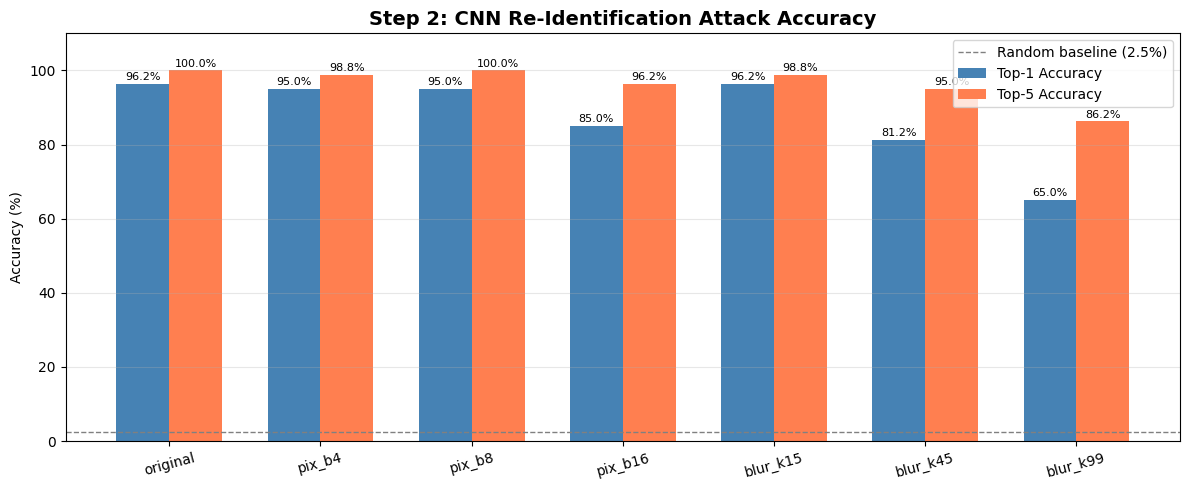

Saved: step2_attack_results.png


In [13]:
plot_attack_results(results)

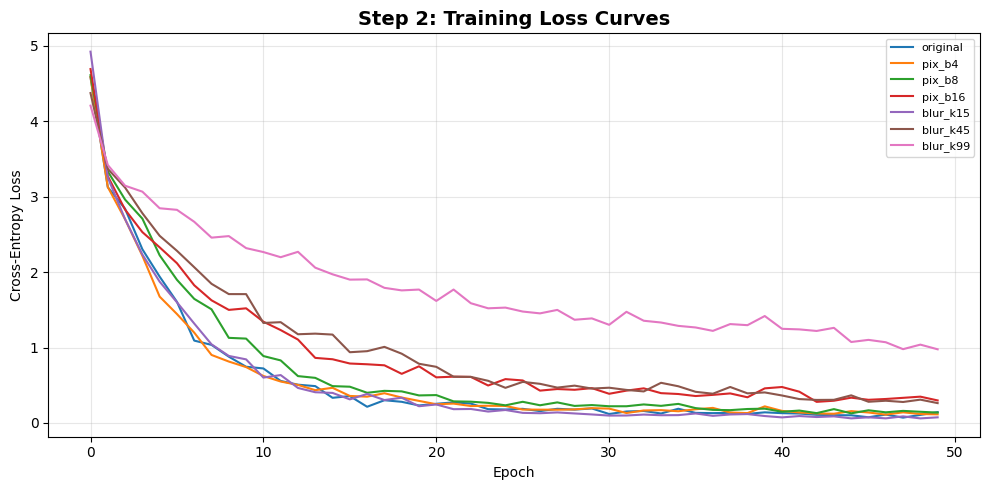

Saved: step2_loss_curves.png


In [14]:
plot_loss_curves(results)


# Step 3

In [15]:
save_dp_dataset(
    images, labels,
    epsilons=[0.1, 0.5, 1.0],
    block_size=16, kernel_size=99,
    out_dir='/content/drive/MyDrive/DPAS/HW3/processed_faces'
)

DP dataset saved to '/content/drive/MyDrive/HW3/processed_faces/'
  Variants: dp_pix and dp_blur for epsilon = [0.1, 0.5, 1.0]


In [16]:
# Run CNN attack on DP variants
dp_results = run_dp_attack(
    processed_dir='/content/drive/MyDrive/DPAS/HW3/processed_faces',
    epsilons=[0.1, 0.5, 1.0],
    num_epochs=50,
    batch_size=32,
)

Using device: cuda

── Training on: pix_b16 ──────────────────────
  Epoch [10/50] Loss: 1.2080
  Epoch [20/50] Loss: 0.5497
  Epoch [30/50] Loss: 0.3405
  Epoch [40/50] Loss: 0.3077
  Epoch [50/50] Loss: 0.2270
  -> Top-1: 81.25%  |  Top-5: 96.25%

── Training on: blur_k99 ──────────────────────
  Epoch [10/50] Loss: 2.4688
  Epoch [20/50] Loss: 1.8121
  Epoch [30/50] Loss: 1.4623
  Epoch [40/50] Loss: 1.3126
  Epoch [50/50] Loss: 1.1655
  -> Top-1: 67.50%  |  Top-5: 88.75%

── Training on: dp_pix_e0.1 ──────────────────────
  Epoch [10/50] Loss: 3.6896
  Epoch [20/50] Loss: 3.6895
  Epoch [30/50] Loss: 3.6894
  Epoch [40/50] Loss: 3.6893
  Epoch [50/50] Loss: 3.6893
  -> Top-1: 2.50%  |  Top-5: 12.50%

── Training on: dp_blur_e0.1 ──────────────────────
  Epoch [10/50] Loss: 3.6895
  Epoch [20/50] Loss: 3.6895
  Epoch [30/50] Loss: 3.6893
  Epoch [40/50] Loss: 3.6893
  Epoch [50/50] Loss: 3.6892
  -> Top-1: 2.50%  |  Top-5: 12.50%

── Training on: dp_pix_e0.5 ──────────────────────
 

In [17]:
print_dp_results_table(dp_results, epsilons=[0.1, 0.5, 1.0])


             Random   NP-Pix DP-Pix e=0.1 DP-Pix e=0.5 DP-Pix e=1.0  NP-Blur DP-Blur e=0.1 DP-Blur e=0.5 DP-Blur e=1.0
Top-1 (%)      2.50    81.25         2.50         6.25        20.00    67.50          2.50          2.50          7.50
Top-5 (%)      2.50    96.25        12.50        16.25        56.25    88.75         12.50         12.50         28.75


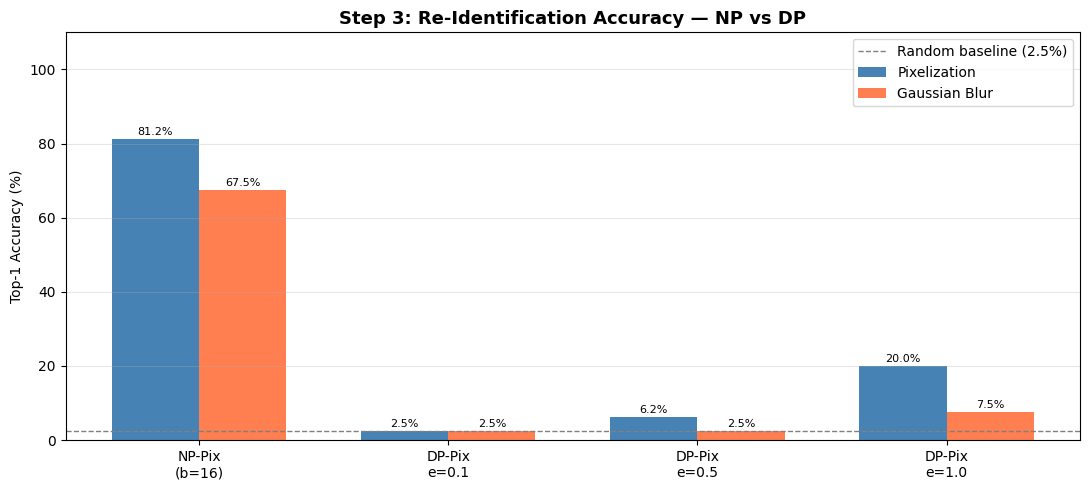

Saved: step3_attack_results.png


In [18]:
plot_dp_attack_results(dp_results, epsilons=[0.1, 0.5, 1.0])

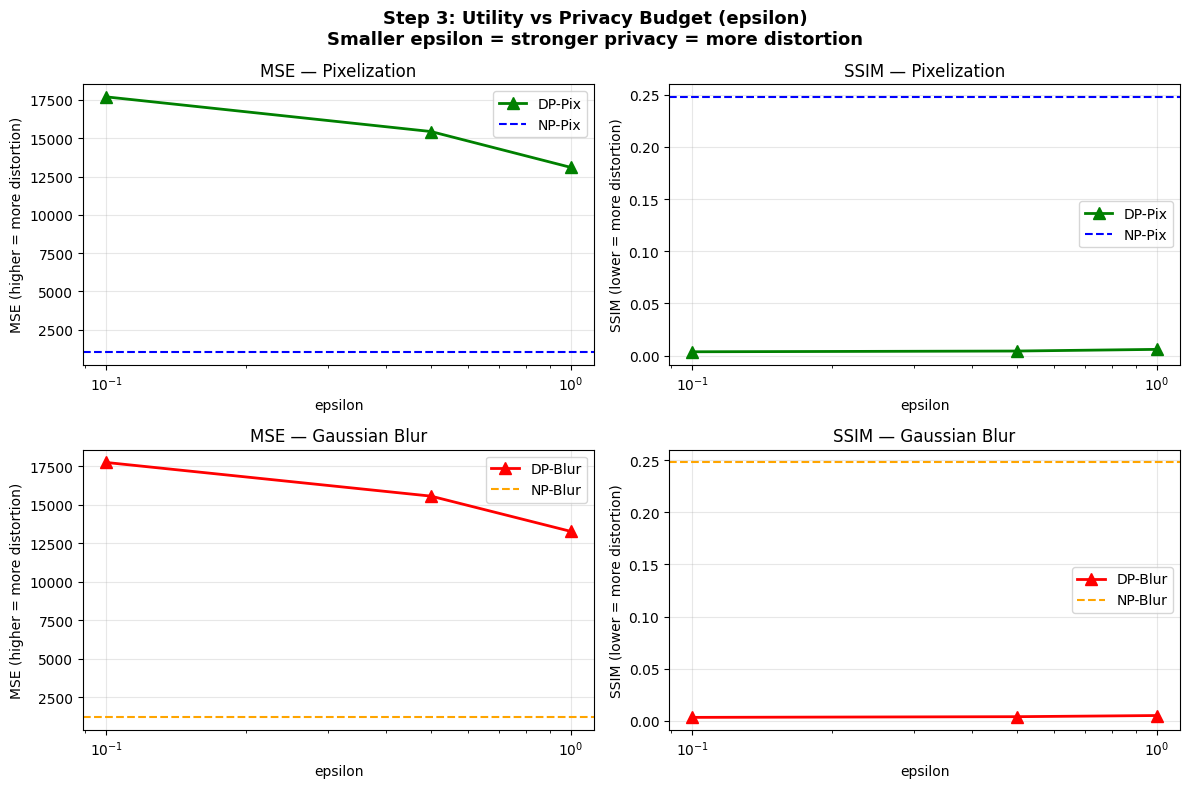

Saved: step3_dp_metrics.png


In [19]:
plot_dp_metrics(images, epsilons=[0.1, 0.5, 1.0], block_size=16, kernel_size=99)

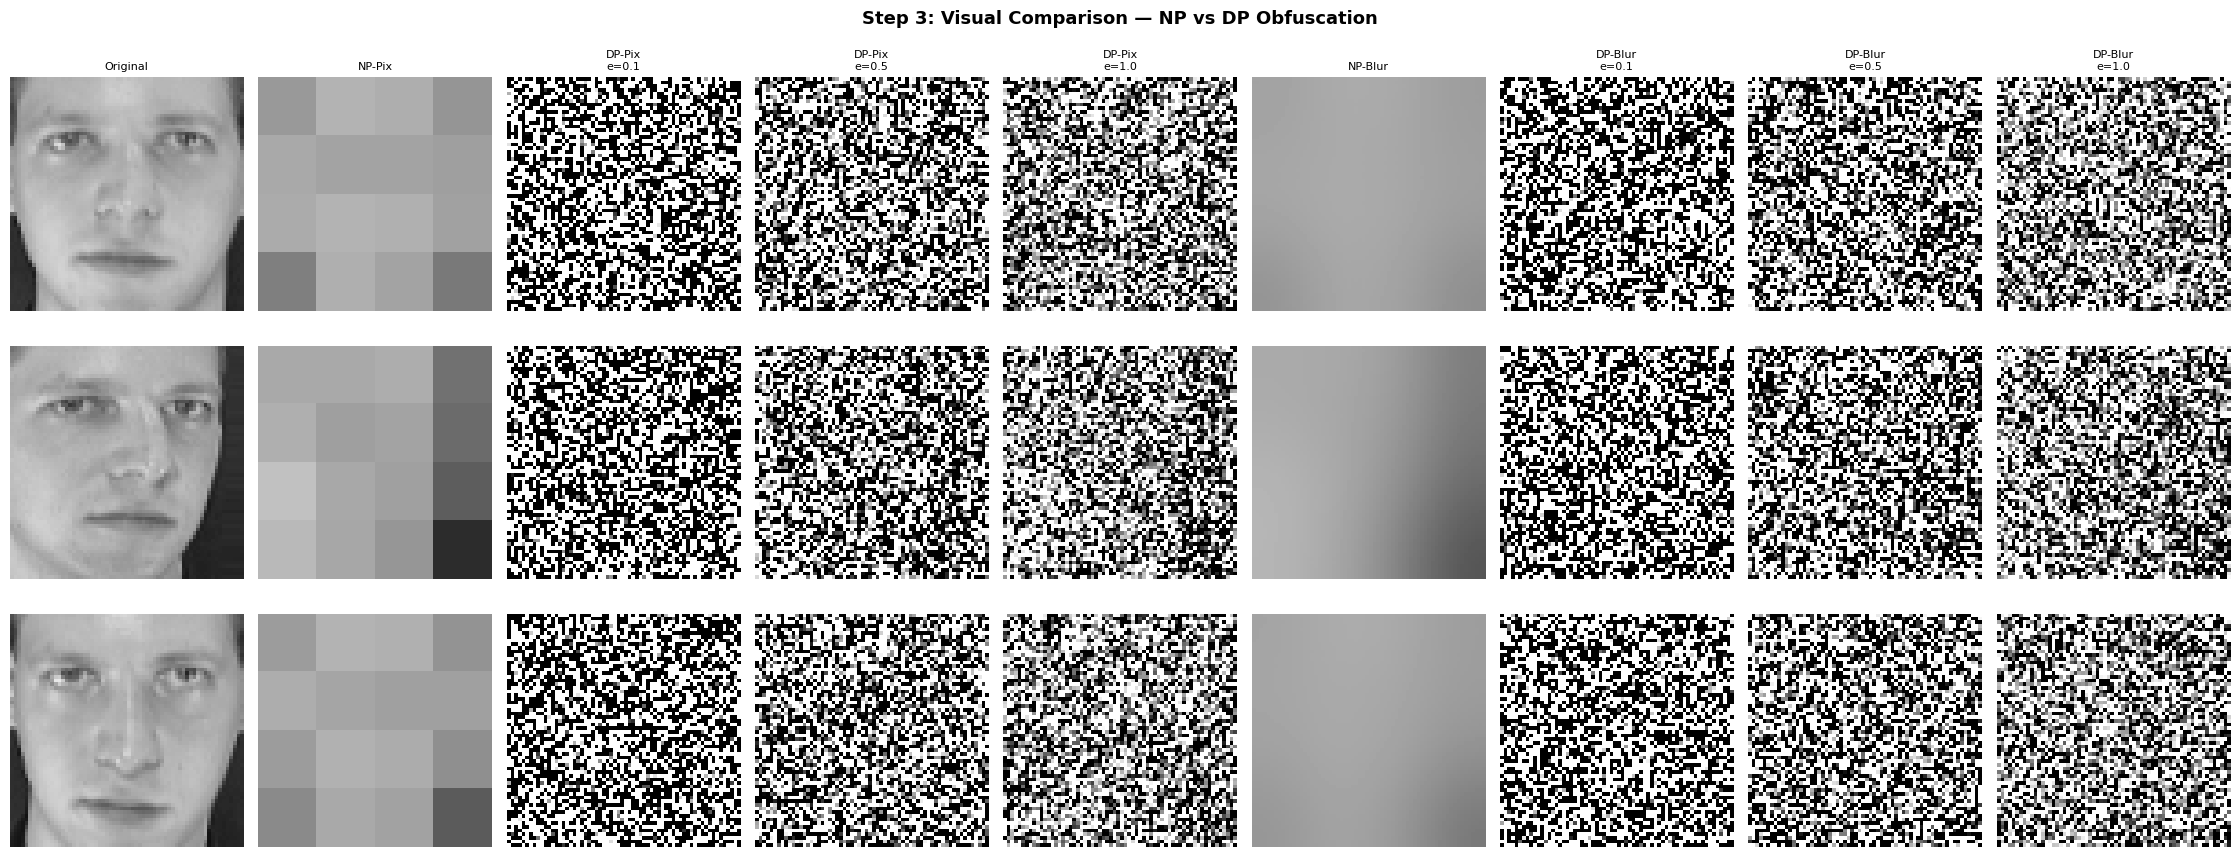

Saved: step3_dp_visual.png


In [20]:
plot_dp_visual_comparison(images, epsilons=[0.1, 0.5, 1.0], block_size=16, kernel_size=99)